# 09 - Business Insights & Prediction

Goal: apply the final model to `Joined` customers, create risk tiers, and export tables ready for Power BI.

In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

PROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"

final = joblib.load(f"{MODELS_DIR}/final_model.joblib")
model, threshold, model_name = final["model"], final["threshold"], final["model_name"]

joined_encoded = pd.read_parquet(f"{PROCESSED_DIR}/joined_encoded.parquet")
X_joined = joined_encoded.drop(columns=["Customer_ID"])

print(f"Final model: {model_name} (threshold={threshold:.3f})")
print(f"Joined customers to score: {X_joined.shape[0]}")

Final model: logistic_regression (threshold=0.255)
Joined customers to score: 405


## Score and segment into risk tiers

In [2]:
churn_risk_score = model.predict_proba(X_joined)[:, 1]

# Tiers are tied to the operational threshold (`threshold`, chosen in 08 by recall with
# precision >= 0.55) instead of independent fixed cutoffs. Previously, High/Medium/Low used
# 0.80/0.60 unrelated to the decision threshold -- result: customers the model flagged as
# churn (score >= threshold) could fall into the "Low" tier. With this, the tier never
# contradicts the `predicted_churn` flag.
HIGH_RISK_CUTOFF = 0.60  # within those predicted as churn, contact priority

def tier(score):
    if score >= HIGH_RISK_CUTOFF:
        return "High"
    if score >= threshold:
        return "Medium"
    return "Low"

df_joined_scored = pd.DataFrame({
    "Customer_ID": joined_encoded["Customer_ID"],
    "churn_risk_score": churn_risk_score,
    "risk_tier": [tier(s) for s in churn_risk_score],
    "predicted_churn": (churn_risk_score >= threshold).astype(int),
})

df_joined_scored["risk_tier"] = pd.Categorical(
    df_joined_scored["risk_tier"], categories=["Low", "Medium", "High"], ordered=True
)

print(df_joined_scored["churn_risk_score"].describe())
print()
print(df_joined_scored["risk_tier"].value_counts().sort_index())
print()
print(f"Predicted churners (score >= {threshold:.3f}): {df_joined_scored['predicted_churn'].sum()}")

count    405.000000
mean       0.418970
std        0.239822
min        0.004509
25%        0.200909
50%        0.395096
75%        0.615313
max        0.966253
Name: churn_risk_score, dtype: float64

risk_tier
Low       125
Medium    170
High      110
Name: count, dtype: int64

Predicted churners (score >= 0.255): 280


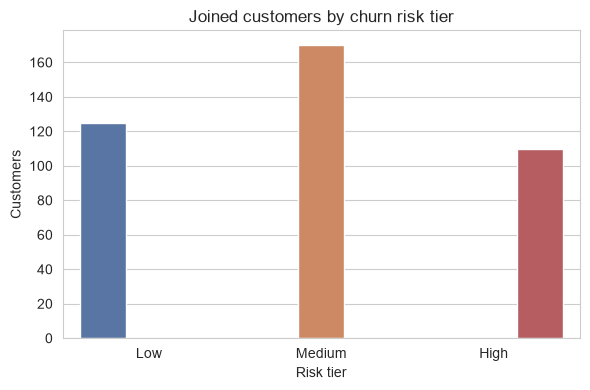

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_joined_scored, x="risk_tier", order=["Low", "Medium", "High"], hue="risk_tier", palette=["#4C72B0", "#DD8452", "#C44E52"], legend=False)
plt.title("Joined customers by churn risk tier")
plt.xlabel("Risk tier")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

## Final model feature importance

For Logistic Regression, standardized coefficients are used: the absolute value measures importance and the sign indicates whether the variable pushes risk up or down.

For tree-based models, `feature_importances_` is used.

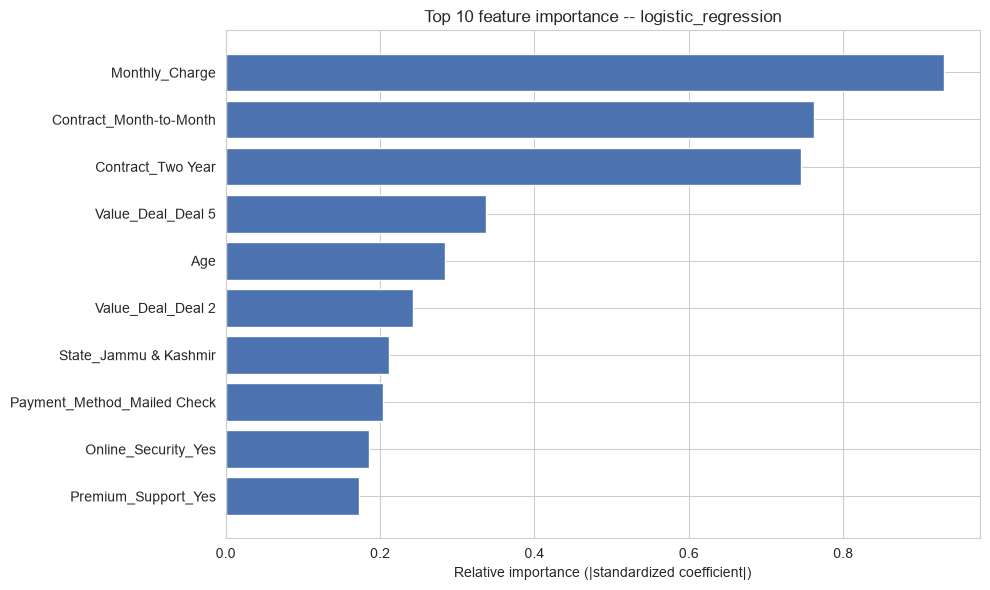

,feature,importance,signed_coefficient,rank
0,Monthly_Charge,0.930587,0.930587,1
1,Contract_Month-to-Month,0.761507,0.761507,2
2,Contract_Two Year,0.745168,-0.745168,3
3,Value_Deal_Deal 5,0.336550,0.336550,4
4,Age,0.284301,0.284301,5
5,Value_Deal_Deal 2,0.242499,-0.242499,6
6,State_Jammu & Kashmir,0.212156,0.212156,7
7,Payment_Method_Mailed Check,0.203489,0.203489,8
8,Online_Security_Yes,0.185267,-0.185267,9
9,Premium_Support_Yes,0.172512,-0.172512,10


In [4]:
estimator = model.named_steps["clf"] if hasattr(model, "named_steps") else model

if hasattr(estimator, "feature_importances_"):
    importance = pd.Series(estimator.feature_importances_, index=X_joined.columns)
    signed_coefficient = pd.Series(0.0, index=X_joined.columns)  # no direction for tree models
else:
    signed_coefficient = pd.Series(estimator.coef_[0], index=X_joined.columns)
    importance = signed_coefficient.abs()

df_feature_importance = pd.DataFrame({
    "feature": importance.index,
    "importance": importance.values,
    "signed_coefficient": signed_coefficient.loc[importance.index].values,
}).sort_values("importance", ascending=False).reset_index(drop=True)
df_feature_importance["rank"] = df_feature_importance.index + 1

plt.figure(figsize=(10, 6))
top10 = df_feature_importance.head(10)
plt.barh(top10["feature"][::-1], top10["importance"][::-1], color="#4C72B0")
plt.title(f"Top 10 feature importance -- {model_name}")
plt.xlabel("Relative importance (|standardized coefficient|)")
plt.tight_layout()
plt.show()

df_feature_importance.head(10)

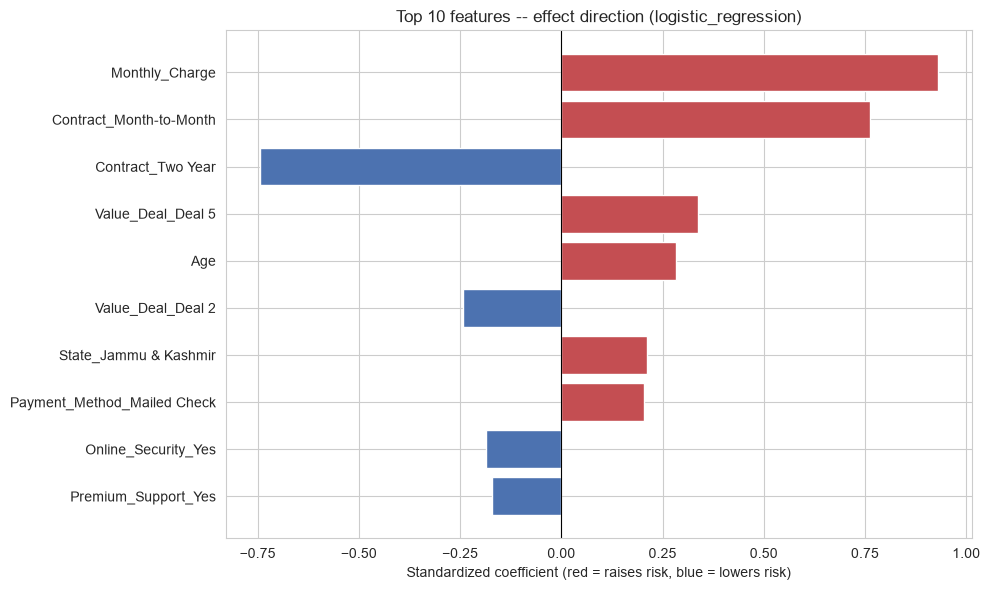

In [5]:
if (df_feature_importance["signed_coefficient"] != 0).any():
    top10_signed = df_feature_importance.head(10).sort_values("importance")
    colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top10_signed["signed_coefficient"]]

    plt.figure(figsize=(10, 6))
    plt.barh(top10_signed["feature"], top10_signed["signed_coefficient"], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title(f"Top 10 features -- effect direction ({model_name})")
    plt.xlabel("Standardized coefficient (red = raises risk, blue = lowers risk)")
    plt.tight_layout()
    plt.show()
else:
    print("Tree-based model: no effect direction available (signed_coefficient = 0).")

In [6]:
df_feature_importance.to_csv(f"{PROCESSED_DIR}/model_feature_importance.csv", index=False)
print("Saved: model_feature_importance.csv")

Saved: model_feature_importance.csv


## Save the table for the dashboard

In [7]:
df_joined_scored.to_csv(f"{PROCESSED_DIR}/joined_scored.csv", index=False)
print("Saved: joined_scored.csv")
df_joined_scored.head()

Saved: joined_scored.csv


,Customer_ID,churn_risk_score,risk_tier,predicted_churn
0,93520-GUJ,0.518241,Medium,1
1,57256-BIH,0.127368,Low,0
2,72357-MAD,0.631431,High,1
3,66612-KAR,0.151594,Low,0
4,22119-WES,0.131719,Low,0


## Conclusion

- The final model was chosen by recall and tuned with an operational threshold oriented toward retention.
- `joined_scored.csv` contains `Customer_ID`, `churn_risk_score`, `risk_tier`, and `predicted_churn` for valid `Joined` customers.
- The tiers are aligned with the threshold: `Low` is below the operational cutoff, `Medium` runs from the cutoff to `0.60`, and `High` is from `0.60` up.
- `model_feature_importance.csv` keeps importance and sign to explain which variables increase or reduce risk.
- These outputs feed the dbt ML layer and the Power BI dashboard.